Generating Extreme Event data for AMAS Project

from gaussian distribution

interested in the upper tail extremes

data is cut away 5 sigma from origin


original code by peter resch, 12.3.2026

In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from matplotlib.markers import MarkerStyle
import os

my_cmap = plt.colormaps["turbo"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["figure.figsize"]='6,3'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')

r = np.random
r.seed(42)

save_figures = False

## #read in file

In [132]:
print(os.getcwd())
#os.chdir("code/VWLS/")

/media/peter/OPENSTORAGE/PhysicsMSc/_Advanced Statistics/_Project/code/VWLS


In [133]:
"""dataset location"""
filename="gauss-mu=5,sigma=2.0,N=e9,cutoff=4sig.csv"
directory = "../data/generating_data_gauss"
filepath = directory+ "/" + filename
print(f"Filepath: {filepath}")

Filepath: ../data/generating_data_gauss/gauss-mu=5,sigma=2.0,N=e9,cutoff=4sig.csv


In [134]:
"""read the values from the text file"""
extreme_values_from_file = []
with open(filepath, "r") as f:
    for line in f:
        extreme_values_from_file.append(float(line.strip()))

print(f"Number of extreme values: {len(extreme_values_from_file)}")

Number of extreme values: 33402


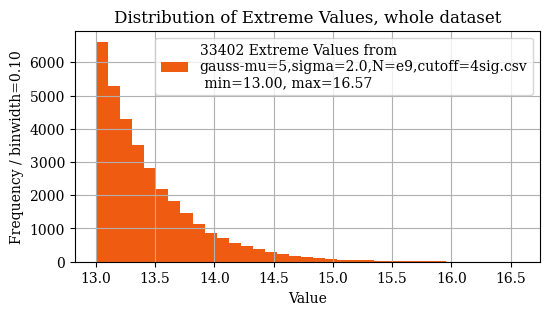

In [135]:
"""illustrating the distribution of the extreme values with a histogram"""
min_value = min(extreme_values_from_file)
max_value = max(extreme_values_from_file)
#n_bins = 50
bin_width = 0.1
n_bins = int((max_value - min_value) / bin_width)

plt.hist(extreme_values_from_file, bins=n_bins, alpha=1, color=my_cmap(0.8),label=f"{len(extreme_values_from_file)} Extreme Values from\n{filename}\n min={min_value:.2f}, max={max_value:.2f}")
plt.xlabel("Value")
plt.ylabel(f"Frequency / binwidth={bin_width:.2f}")
plt.title("Distribution of Extreme Values, whole dataset")
plt.grid()
plt.legend()
plt.show()

if save_figures:
    plt.savefig(f"{directory}/histogram_extreme_values_{filename}.png")

## #Selecting Distribution and estimating start parameters

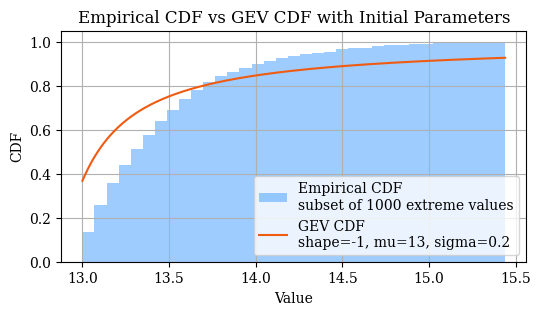

In [136]:
"""define starting parameters for fitting the GEV distribution"""
shape_param = -1
mu_param = 13
sigma_param = 0.2

def gev_cdf(xi_array, shape_param, mu_param, sigma_param):
    return stats.genextreme.cdf(x=xi_array, c=shape_param, loc=mu_param, scale=sigma_param)


"""select a subset of the extreme values for fitting the GEV distribution"""
subset_size = 1000
x_subset=extreme_values_from_file[:subset_size]


"""plotting the empirical CDF of the subset of extreme values and the GEV CDF with the initial parameters"""
x_values = np.linspace(min(x_subset), max(x_subset), 1000)
gev_cdf_values = gev_cdf(x_values, shape_param, mu_param, sigma_param)
plt.hist(x_subset, bins=n_bins, density=True, alpha=0.5, color=my_cmap(0.2), label=f"Empirical CDF\nsubset of {subset_size} extreme values",cumulative=True)
plt.plot(x_values, gev_cdf_values, label=f"GEV CDF\nshape={shape_param}, mu={mu_param}, sigma={sigma_param}", color=my_cmap(0.8))
plt.xlabel("Value")
plt.ylabel("CDF")
plt.title("Empirical CDF vs GEV CDF with Initial Parameters")
plt.grid()
plt.legend()
plt.show()

## #Weibull Plotting Positions

In [ ]:
"""Ranking the subset of data points"""
x_m = np.sort(x_subset)


"""define Weibull plotting positions"""
def weibull_p_m(rank_m, n):
    """ rank_m >= 1
        n = number of data points in the subset"""
    p_m=rank_m / (n + 1)
    #print(f"P(m={rank_m},N={n}) = {p_m:.8f}")
    return p_m


def best_estimate_xi(rank_m,search_min,search_max):
    diff = (search_max - search_min)
    p_m=weibull_p_m(rank_m, subset_size)
    steps=100
    stepsize = diff / steps
    xi_proposal = np.arange(search_min, search_max, stepsize)

    for m in range(steps):
        gev_cdf_value = gev_cdf(xi_proposal[m], shape_param, mu_param, sigma_param)
        #print(f"xi_proposal: {xi_proposal[m]:.4f}, GEV CDF: {gev_cdf_value:.6f}, p_m: {p_m:.6f}")
        if gev_cdf_value >= p_m:
            print(f"Found corresponding xi_m")
            return xi_proposal[m],stepsize
        
    print("Did not find xi_m in this range")
    return None


def best_estimate_xi_with_resolution(rank_m,search_min,search_max,resolution=0.01):
    search_range=search_max-search_min
    i=0

    while search_range>resolution:
        print(f"rank_m: {rank_m},round {i}")

        xi_propose,search_range=best_estimate_xi(rank_m,search_min,search_max)
        if xi_propose == None:
            raise ValueError
            #new iteration with different limits
            #best_estimate_xi_with_resolution
        search_max=xi_propose
        search_min=xi_propose-search_range
    return xi_propose


"""find xi_m, given the rank m"""
def search_xi_m(rank_m, last_xi_m=None,search_min=0, search_max=20):
    p_m=weibull_p_m(rank_m, subset_size)
    
    #iterative method to find xi_m such that the GEV CDF at xi_m is equal to the Weibull plotting position for rank_m
    if last_xi_m is None:
        min = search_min
    else:
        min = last_xi_m
    max = search_max
    diff = (max - min)
    resolution = 0.00001
    i=0

    while diff > resolution:
        print(f"rank_m: {rank_m},round {i}")
        #  min: {min:.4f}, max: {max:.4f}, diff: {diff:.4f}")
        stepsize = diff / 100
        xi_proposal = np.arange(min, max, stepsize)
        xi_m_above=0

        for m in range(len(xi_proposal)):
            gev_cdf_value = gev_cdf(xi_proposal[m], shape_param, mu_param, sigma_param)
            #print(f"xi_proposal: {xi_proposal[m]:.4f}, GEV CDF: {gev_cdf_value:.6f}, p_m: {p_m:.6f}")
            if gev_cdf_value >= p_m:
                xi_m_above = xi_proposal[m]
                xi_m_below = xi_proposal[m-1]
                print(f"Found xi_m above p_m: {xi_m_above:.4f}, GEV CDF at xi_m: {gev_cdf_value:.6f}, p_m: {p_m:.6f}")
                break
        if xi_m_above == 0:#did not reach the desired p_m, so we need to expand the search range
            xi_m_above=max*100
            xi_m_below=max
            print(f"Did not reach desired p_m, expanding search range to min:max: {xi_m_below:.4f}:{xi_m_above:.4f}")
        
        max=xi_m_above
        min=xi_m_below
        diff = max-min
        #print(f"\n diff: {diff:.4f}, xi_m_below: {xi_m_below:.4f}, xi_m_above: {xi_m_above:.4f}")
        i+=1

        if diff < 0 :#in the case that the search range is too high and we need to shift it downwards
            min = xi_m_above-stepsize*100
            max = xi_m_above
            diff = max-min
            print(f"shifting search range to min: {min:.4f}, max: {max:.4f}, diff: {diff:.4f}")
    return max

raise NotImplementedError
def find_all_xi_m(ranks_m):
    xi_m=np.zeros_like(ranks_m, dtype=float)
    for rank in ranks_m:
        xi_m[rank-1] = search_xi_m(rank, last_xi_m=xi_m[rank-2] if rank > 1 else None,search_min=x_m[0],search_max=x_m[-1])
        print(f"Calculated xi_m for rank {rank}/{subset_size}", end="\r")
    xi_m = np.array(xi_m)
    return xi_m


#testing
rank_m =329
xi_values = search_xi_m(rank_m)

print(f"cdf(m={rank_m}) = {gev_cdf(xi_values, shape_param, mu_param, sigma_param):.8f}")
print(f"xi(m={rank_m}) = {xi_values:.4f}")
print(f"P(m={rank_m},N={subset_size}) = {weibull_p_m(rank_m, subset_size):.8f}")
print(f"x(m={rank_m}) = {x_m[rank_m]:.4f}")
print(f"Difference between GEV CDF at xi_m and Weibull plotting position: {gev_cdf(xi_values, shape_param, mu_param, sigma_param) - weibull_p_m(rank_m, subset_size):.8f}")

rank_m: 329,round 0
Found xi_m above p_m: 13.0000, GEV CDF at xi_m: 0.367879, p_m: 0.328671
rank_m: 329,round 1
Found xi_m above p_m: 12.9800, GEV CDF at xi_m: 0.329193, p_m: 0.328671
rank_m: 329,round 2
Found xi_m above p_m: 12.9798, GEV CDF at xi_m: 0.328705, p_m: 0.328671
rank_m: 329,round 3
Found xi_m above p_m: 12.9797, GEV CDF at xi_m: 0.328672, p_m: 0.328671
cdf(m=329) = 0.32867164
xi(m=329) = 12.9797
P(m=329,N=1000) = 0.32867133
x(m=329) = 13.1855
Difference between GEV CDF at xi_m and Weibull plotting position: 0.00000031


In [170]:
xi_m[329]

np.float64(12.980298448781303)

In [177]:
"""calculating plotting positions and corresponding xi_m for the ranked data points"""
ranks_m = np.arange(1, subset_size + 1)
p_m = weibull_p_m(ranks_m, n=subset_size)

xi_m = find_all_xi_m(ranks_m)

rank_m: 1,round 0
Found xi_m above p_m: 13.0001, GEV CDF at xi_m: 0.367978, p_m: 0.000999
shifting search range to min: 10.5600, max: 13.0001, diff: 2.4400
rank_m: 1,round 1
Found xi_m above p_m: 12.8293, GEV CDF at xi_m: 0.001073, p_m: 0.000999
rank_m: 1,round 2
Found xi_m above p_m: 12.8290, GEV CDF at xi_m: 0.001013, p_m: 0.000999
rank_m: 1,round 3
Found xi_m above p_m: 12.8290, GEV CDF at xi_m: 0.001000, p_m: 0.000999
rank_m: 2,round 0or rank 1/1000
Found xi_m above p_m: 12.8551, GEV CDF at xi_m: 0.026457, p_m: 0.001998
rank_m: 2,round 1
Found xi_m above p_m: 12.8323, GEV CDF at xi_m: 0.002064, p_m: 0.001998
rank_m: 2,round 2
Found xi_m above p_m: 12.8322, GEV CDF at xi_m: 0.001998, p_m: 0.001998
rank_m: 3,round 0or rank 2/1000
Found xi_m above p_m: 12.8583, GEV CDF at xi_m: 0.032289, p_m: 0.002997
rank_m: 3,round 1
Found xi_m above p_m: 12.8345, GEV CDF at xi_m: 0.003049, p_m: 0.002997
rank_m: 3,round 2


Found xi_m above p_m: 12.8344, GEV CDF at xi_m: 0.002998, p_m: 0.002997
rank_m: 4,round 0or rank 3/1000
Found xi_m above p_m: 12.8605, GEV CDF at xi_m: 0.036631, p_m: 0.003996
rank_m: 4,round 1
Found xi_m above p_m: 12.8362, GEV CDF at xi_m: 0.004016, p_m: 0.003996
rank_m: 4,round 2
Found xi_m above p_m: 12.8362, GEV CDF at xi_m: 0.003996, p_m: 0.003996
rank_m: 5,round 0or rank 4/1000
Found xi_m above p_m: 12.8623, GEV CDF at xi_m: 0.040252, p_m: 0.004995
rank_m: 5,round 1
Found xi_m above p_m: 12.8378, GEV CDF at xi_m: 0.005022, p_m: 0.004995
rank_m: 5,round 2
Found xi_m above p_m: 12.8377, GEV CDF at xi_m: 0.004996, p_m: 0.004995
rank_m: 6,round 0or rank 5/1000
Found xi_m above p_m: 12.8638, GEV CDF at xi_m: 0.043435, p_m: 0.005994
rank_m: 6,round 1
Found xi_m above p_m: 12.8393, GEV CDF at xi_m: 0.006167, p_m: 0.005994
rank_m: 6,round 2
Found xi_m above p_m: 12.8391, GEV CDF at xi_m: 0.005996, p_m: 0.005994
rank_m: 7,round 0or rank 6/1000
Found xi_m above p_m: 12.8651, GEV CDF at xi

KeyboardInterrupt: 

In [ ]:
"""Illustrating the ranked data points and their Weibull plotting positions"""
fig,[ax_weibull,ax_cdf]=plt.subplots(1,2,figsize=(12,4))

ax_weibull.plot(x_m, p_m, color=my_cmap(0.2), label=f"Weibull Plotting Positions, m_max={subset_size}", marker='.', linestyle='-')
ax_weibull.set_xlabel("x(m)")
ax_weibull.set_ylabel("Weibull Plotting Position P(m)")
ax_weibull.set_title("Weibull Plotting Positions vs Ranks")
ax_weibull.grid()
ax_weibull.legend()


ax_cdf.plot(xi_m,gev_cdf(xi_m,shape_param,mu_param,sigma_param), color=my_cmap(0.8), label="Ranked Data Points", marker=my_marker, linestyle='--')
ax_cdf.set_xlabel("xi(m)")
ax_cdf.set_ylabel("CDF")
ax_cdf.set_title("CDF vs Ranked Data Points")
ax_cdf.grid()
ax_cdf.legend()

KeyboardInterrupt: 

## #Weighing and fitting - functions

## #Reject data - function

## #Fitting process